# PollenBB16 — minimal reproduction: selective archive access, annotation inspection, morphometrics, and the author's bbox script

**Paper:** Sanhueza I. et al., *"A High-Resolution Multifocal RGB Pollen Grain Image Dataset for Deep Learning Computer Vision Tasks from Biobío Region, Chile."* **Scientific Data 13:1076 (2026)**, DOI [10.1038/s41597-026-07495-7](https://doi.org/10.1038/s41597-026-07495-7). Dataset: Zenodo DOI [10.5281/zenodo.19830051](https://doi.org/10.5281/zenodo.19830051) (CC BY 4.0).

**Scope of this notebook (one-example demonstration, not a full reproduction):**
1. Selectively retrieve a deterministic sample (images + labels + the author's script) from the single 43.9 GB Zenodo archive using HTTP-Range reads of the ZIP central directory — **no full download**.
2. Inspect the paper's 3-plane multifocal z-stack (fp0/fp1/fp2) and the expert-verified YOLO-seg polygon annotations.
3. Recompute the paper's per-grain **morphometric descriptors** (Methods → *Morphometric Characterization of the Annotations*) and compare against the published in-text Table 6 row for *Gevuina avellana*.
4. Re-run the paper's **only distributed custom code**, `scripts/polygons_to_bboxes.py`, and check it regenerates the author-distributed `labels_bb/` file exactly.

**Out of scope / not attempted:** the 50-epoch YOLO11n-seg baseline training (11,333 images at native 3088×2064) is far beyond a free Colab session, and the paper's trained checkpoint is not distributed; per-class Table 7 metrics, dataset-wide statistics, and the inter-annotator study are not reproduced.

**実行環境の選択：** このデモは CPU だけで完結します（ランタイム类型 → **CPU**）。GPU は不要です。全体の想定時間は数分、ダウンロードは約 30–80 MB（アーカイブ全体 43.9 GB のうちの断片のみ）です。**Run all** で最初から最後まで実行できます。


## 1 · Runtime selection / ランタイムの選択

**Select `Runtime → Change runtime type → CPU` in Colab.** The demonstration performs polygon rasterization and shape measurements on a handful of 6.4-megapixel images; no GPU operation is involved. The paper's deep-learning baseline is explicitly out of scope (see above), so no accelerator is requested.

**CPU を選択してください。** GPU は不要です。実行時間の目安：数分。ダウンロード：約 30–80 MB。

## 2 · Locate the archive through the Zenodo record API / Zenodo レコード API でアーカイブを特定

The paper's Data Records section states the dataset is released at Zenodo DOI `10.5281/zenodo.19830051` under CC BY 4.0. We query the documented public record API and take the **content link returned by the record itself** (never a guessed URL), together with the recorded file size and MD5 for provenance. Expected result: one file `pollenbb16.zip`, 43,910,087,332 bytes.

In [ ]:
import json, time
import requests

t_notebook_start = time.time()
RECORD_ID = "19830051"   # Zenodo record for PollenBB16 (paper Data Records section)
rec = requests.get(f"https://zenodo.org/api/records/{RECORD_ID}", timeout=60)
rec.raise_for_status()
rec = rec.json()
meta_title = rec["metadata"]["title"]
assert "Pollen" in meta_title and "Chile" in meta_title, meta_title
assert rec["metadata"]["license"]["id"] == "cc-by-4.0", rec["metadata"]["license"]

files = rec["files"]
assert len(files) == 1, [f["key"] for f in files]
fn = files[0]
CONTENT_URL = fn["links"]["self"]          # content URL returned by the record API
print("title :", meta_title)
print("doi   :", rec["doi"])
print("license:", rec["metadata"]["license"]["id"])
print("file  :", fn["key"], fn["size"], "bytes |", fn["checksum"])

title : A High-Resolution Multifocal RGB Pollen Grain Image Dataset for Deep Learning Computer Vision Tasks from Biobío Region, Chile
doi   : 10.5281/zenodo.19830051
license: cc-by-4.0
file  : pollenbb16.zip 43910087332 bytes | md5:0d9ff5a745e54daa3419aca68c929712


The record confirms a **single 43.9 GB ZIP** — downloading it entirely (~44 GB) is impractical in Colab and unnecessary for a one-example demonstration. Instead, the next cells read only the bytes we need.

レコードは単一の 43.9 GB ZIP です。必要な断片だけを HTTP Range リクエストで取得します。

### 2.1 · Verify HTTP-Range support / Range リクエストの確認

Selective extraction requires the server to honour `Range` requests. A 1-byte ranged GET must answer `206` with the archive's total size in `Content-Range`, and the response should advertise `Accept-Ranges: bytes`. If this fails we stop rather than fall back to a 44 GB download.

In [ ]:
s = requests.Session()
r = s.get(CONTENT_URL, headers={"Range": "bytes=0-0"}, timeout=60)
print("status:", r.status_code, "| content-range:", r.headers.get("Content-Range"),
      "| accept-ranges:", r.headers.get("Accept-Ranges"))
assert r.status_code == 206, "server does not support Range requests"
TOTAL_SIZE = int(r.headers["Content-Range"].split("/")[-1])
assert TOTAL_SIZE == fn["size"], (TOTAL_SIZE, fn["size"])
print("archive size verified:", TOTAL_SIZE)

status: 206 | content-range: bytes 0-0/43910087332 | accept-ranges: bytes
archive size verified: 43910087332


### 2.2 · Read the ZIP central directory / ZIP 中央ディレクトリの取得

The archive is larger than 4 GiB, so it uses ZIP64. We locate the ZIP64 end-of-central-directory record in the last megabyte of the file, then download the central directory (~6.4 MB) in parallel ranged chunks. This costs seconds and a few megabytes instead of 44 GB.

4 GiB 超のため ZIP64 形式です。末尾 1 MiB から EOCD を探し、中央ディレクトリ（約 6.4 MB）を並列 Range 取得します。

In [ ]:
import struct, concurrent.futures as cf

tail = s.get(CONTENT_URL, headers={"Range": f"bytes={TOTAL_SIZE-1048576}-{TOTAL_SIZE-1}"}, timeout=120).content
assert len(tail) == 1048576
i = tail.rfind(b"PK\x06\x07")                       # ZIP64 EOCD locator
assert i >= 0, "no ZIP64 EOCD locator"
_, _disk, eocd64_off, _ = struct.unpack("<IIQI", tail[i:i+20])
j = TOTAL_SIZE - 1048576
if eocd64_off >= j:                                   # usually inside the tail we already fetched
    eocd = tail[eocd64_off - j:]
else:
    eocd = s.get(CONTENT_URL, headers={"Range": f"bytes={eocd64_off}-{eocd64_off+55}"}, timeout=60).content
assert eocd[:4] == b"PK\x06\x06"
cd_size, cd_off = struct.unpack("<QQ", eocd[40:56])
print(f"central directory: offset={cd_off}, size={cd_size/1e6:.1f} MB")

t0 = time.time()
CHUNK = 4 * 1024 * 1024
def fetch_chunk(a, b):
    for attempt in range(4):
        try:
            rr = s.get(CONTENT_URL, headers={"Range": f"bytes={a}-{b}"}, timeout=180)
            if rr.status_code == 206 and len(rr.content) == b - a + 1:
                return rr.content
        except Exception:
            if attempt == 3:
                raise
ranges = [(cd_off + k, min(cd_off + k + CHUNK, cd_off + cd_size) - 1) for k in range(0, cd_size, CHUNK)]
with cf.ThreadPoolExecutor(12) as ex:
    cd_bytes = b"".join(list(ex.map(lambda ab: fetch_chunk(*ab), ranges)))
assert len(cd_bytes) == cd_size
print(f"fetched {len(cd_bytes)/1e6:.1f} MB in {time.time()-t0:.1f}s")

central directory: offset=43903720748, size=6.4 MB


fetched 6.4 MB in 3.8s


### 2.3 · Parse the central directory / 中央ディレクトリの解析

Each central-directory entry carries the member name, CRC-32, sizes and local-header offset (ZIP64 extended fields included). Expected layout per the paper's Data Records section: `pollenbb16/{images,labels,labels_bb,splits,scripts}` plus `data_split.yaml`, with **16,198 JPEG images**.

In [ ]:
def parse_cd(buf):
    entries, pos, n = [], 0, len(buf)
    while True:
        pos = buf.find(b"PK\x01\x02", pos)
        if pos < 0 or pos + 46 > n:
            break
        (_sig, _vm, _vn, _fl, method, _mt, _md,
         crc, csize, usize, nlen, elen, clen, _dk, _ia, _ea, lho) = struct.unpack(
            "<IHHHHHHIIIHHHHHII", buf[pos:pos+46])
        name = buf[pos+46:pos+46+nlen].decode("utf-8", "replace")
        extra = buf[pos+46+nlen:pos+46+nlen+elen]
        e = 0                                              # ZIP64 extended-information field
        while e + 4 <= len(extra):
            hid, hsz = struct.unpack("<HH", extra[e:e+4])
            if hid == 0x0001:
                body = extra[e+4:e+4+hsz]; b = 0
                if usize == 0xFFFFFFFF and b + 8 <= len(body): usize, = struct.unpack("<Q", body[b:b+8]); b += 8
                if csize == 0xFFFFFFFF and b + 8 <= len(body): csize, = struct.unpack("<Q", body[b:b+8]); b += 8
                if lho  == 0xFFFFFFFF and b + 8 <= len(body): lho,  = struct.unpack("<Q", body[b:b+8]); b += 8
            e += 4 + hsz
        entries.append(dict(name=name, crc=crc, csize=csize, usize=usize, lho=lho, method=method))
        pos += 46 + nlen + elen + clen
    return entries

entries = parse_cd(cd_bytes)
names = {e["name"]: e for e in entries}
imgs = [n for n in names if n.startswith("pollenbb16/images/") and n.lower().endswith(".jpg")]
print("total members:", len(entries), "| images:", len(imgs))
assert len(imgs) == 16198, len(imgs)
from collections import Counter
print("top-level breakdown:")
for k, v in sorted(Counter("/".join(n.split("/")[:2]) for n in names if n.count("/") >= 1).items()):
    print(f"  {k:35s} {v}")

total members: 48615 | images: 16198
top-level breakdown:
  pollenbb16/                         1
  pollenbb16/data_split.yaml          1
  pollenbb16/images                   16199
  pollenbb16/labels                   16199
  pollenbb16/labels_bb                16209
  pollenbb16/scripts                  2
  pollenbb16/splits                   4


The layout matches the paper exactly. Note there is **no `analysis/` directory inside the archive** — the Usage Notes' "project repository" analysis notebooks are not part of the Zenodo release; they are not needed for this demonstration.

レイアウトは論文の記述と一致します（`analysis/` ノートブックは ZIP 内に存在しません）。

## 3 · Class map and leakage-safe splits / クラスマップとリーク対策済み分割

Fetch `data_split.yaml` and the three split lists, then verify the published counts — train **11,333**, validation **2,429**, test **2,436** (in-text Table 5) — and the 16-class map used throughout the paper.

In [ ]:
def extract(name):
    """Fetch one member by name through ranged reads; verify CRC-32 of the decompressed bytes."""
    e = names[name]
    hdr = s.get(CONTENT_URL, headers={"Range": f"bytes={e['lho']}-{e['lho']+29}"}, timeout=60).content
    assert hdr[:4] == b"PK\x03\x04"
    nlen, elen = struct.unpack("<HH", hdr[26:30])
    data_start = e["lho"] + 30 + nlen + elen
    comp = s.get(CONTENT_URL, headers={"Range": f"bytes={data_start}-{data_start+e['csize']-1}"}, timeout=300).content
    assert len(comp) == e["csize"], (name, len(comp), e["csize"])
    data = comp if e["method"] == 0 else zlib.decompress(comp, -15)
    assert zlib.crc32(data) & 0xFFFFFFFF == e["crc"], f"CRC mismatch: {name}"
    return data

import zlib
yaml_txt = extract("pollenbb16/data_split.yaml").decode()
print(yaml_txt)
splits = {}
for sp in ["train", "val", "test"]:
    lines = [l.strip() for l in extract(f"pollenbb16/splits/{sp}.txt").decode().splitlines() if l.strip()]
    splits[sp] = lines
    print(f"{sp}: {len(lines)} entries")
assert [len(splits["train"]), len(splits["val"]), len(splits["test"])] == [11333, 2429, 2436]
assert sum(len(v) for v in splits.values()) == 16198

# PollenBB16 (JPEG) -- 70/15/15 leakage-safe split (seed=42)
path: D:\GITHUB_PROJECTS\Paper_Data_RGB_Pollen\pollenbb16jpeg

train: splits/train.txt
val: splits/val.txt
test: splits/test.txt

nc: 16

names:
  0: anthemis_cotula
  1: aristotelia_chilensis
  2: brassica_rapa
  3: castanea_sativa
  4: conium_maculatum
  5: escallonia_pulverulenta
  6: eucryphia_glutinosa
  7: galega_officinalis
  8: gevuina_avellana
  9: lomatia_hirsuta
  10: medicago_sativa
  11: mentha_pulegium
  12: otholobium_glandulosum
  13: quilaja_saponaria
  14: rumex_acetosella
  15: schinus_polygamus



train: 11333 entries


val: 2429 entries


test: 2436 entries


Split sizes match the paper exactly. Each split line is the author's original Windows path; only the file name (species/replicate/stage-coordinates/focal-plane) matters to us.

分割数は論文どおりです（11,333 / 2,429 / 2,436）。各行は作者の Windows パスで、ファイル名に種・スライド複製・ステージ座標・焦点平面がエンコードされています。

## 4 · Deterministic sample: one *Gevuina avellana* z-stack position / 決定論的サンプル選択

Following the paper, every spatial position has three focal planes: **fp0** (optimal focus), **fp1/fp2** (±5 µm). *Gevuina avellana* has the largest grains in the dataset (in-text Table 6: mean area ≈ 1055 µm², circularity ≈ 0.71) and lobed contours, making it a good visual and morphometric test.

**Deterministic rule:** the alphabetically first `val` stem containing `gevuina` (case-insensitive), plus its fp1/fp2 siblings. We fetch the three JPEGs, the polygon labels (`labels/`), the author's bounding boxes (`labels_bb/`), and the author's script `scripts/polygons_to_bboxes.py` — every member CRC-32-verified after decompression.

決定論的規則：val 分割内で `gevuina` を含む名前順最初の画像（fp0）とその fp1/fp2 兄弟、対応ラベル・bbox・作者スクリプトを取得し、各メンバーの CRC-32 を検証します。

In [ ]:
import hashlib
stems = sorted({l.rsplit("\\", 1)[-1].rsplit(".", 1)[0] for l in splits["val"]})
sample_stem = next(st for st in stems if "gevuina" in st.lower())
assert sample_stem.endswith("_fp0"), sample_stem
siblings = [sample_stem[:-1] + "1", sample_stem[:-1] + "2"]   # fp1, fp2
print("sample position:", sample_stem)

fetched = {}
for st in [sample_stem] + siblings:
    fetched[f"pollenbb16/images/{st}.jpg"]   = extract(f"pollenbb16/images/{st}.jpg")
    fetched[f"pollenbb16/labels/{st}.txt"]   = extract(f"pollenbb16/labels/{st}.txt")
    fetched[f"pollenbb16/labels_bb/{st}.txt"] = extract(f"pollenbb16/labels_bb/{st}.txt")
script_bytes = extract("pollenbb16/scripts/polygons_to_bboxes.py")
script_sha = hashlib.sha256(script_bytes).hexdigest()
fetched["pollenbb16/scripts/polygons_to_bboxes.py"] = script_bytes

for k, v in fetched.items():
    print(f"  {k:60s} {len(v):>10,} bytes  sha256={hashlib.sha256(v).hexdigest()[:16]}…")
lbl_txt  = fetched[f"pollenbb16/labels/{sample_stem}.txt"].decode()
lbb_txt  = fetched[f"pollenbb16/labels_bb/{sample_stem}.txt"].decode()
print("\npolygon label lines:", len(lbl_txt.splitlines()), "| bbox label lines:", len(lbb_txt.splitlines()))
print(lbl_txt[:300])

sample position: Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp0


  pollenbb16/images/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp0.jpg  2,726,552 bytes  sha256=f73d18f1a7b67a99…
  pollenbb16/labels/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp0.txt        309 bytes  sha256=c80fa995deb96097…
  pollenbb16/labels_bb/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp0.txt         39 bytes  sha256=a1398ed366e54955…
  pollenbb16/images/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp1.jpg  2,725,453 bytes  sha256=2bdff2f4c7ed1e13…
  pollenbb16/labels/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp1.txt        309 bytes  sha256=c80fa995deb96097…
  pollenbb16/labels_bb/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp1.txt         39 bytes  sha256=a1398ed366e54955…
  pollenbb16/images/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp2.jpg  2,717,065 bytes  sha256=5a4f63a130dd1366…
  pollenbb16/labels/Gevuina_avellana_Biobio_Chile_R05_X4022_Y3148_fp2.txt        309 bytes  sha256=c80fa995deb96097…
  pollenbb16/labels_bb/Gevuina_avellana_Biobio_Chile_R05_X

## 5 · Input preview with the reference annotations / 入力画像と参照アノテーションのプレビュー

This is the paper's raw material: a brightfield 3088×2064 JPEG (Basler acA3088-57ucMED) and the expert-verified YOLO-seg polygons (class 8 = `gevuina_avellana`). The overlay is drawn **from the distributed reference labels**, not from any model prediction — the polygons are rasterized masks, and the dashed rectangles are the author's regenerated bounding boxes for cross-checking.

論文の元画像（3088×2064 輝視野）と、専門家が検証した YOLO-seg ポリゴン（クラス 8 = gevuina_avellana）を重ねて表示します。破線は作者配布の bbox です。

decoded image: (2064, 3088, 3) | polygons: 1 | classes: ['gevuina_avellana']


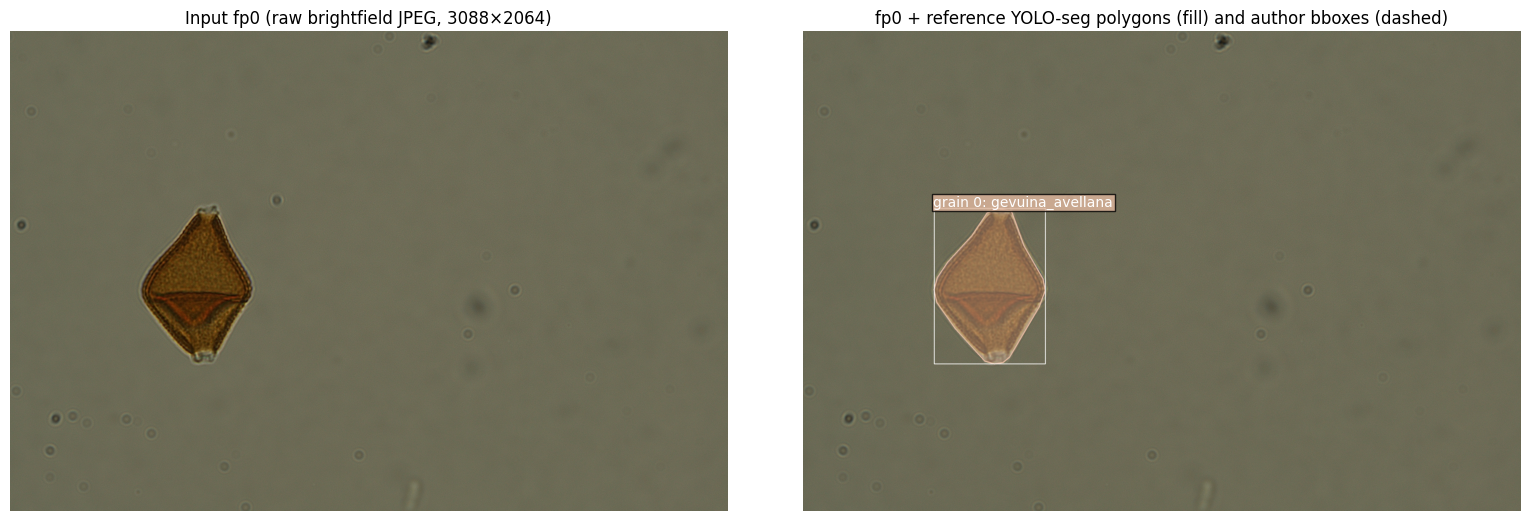

In [ ]:
import io
import numpy as np
import cv2
import matplotlib.pyplot as plt

W, H = 3088, 2064
CLASS_NAMES = {0:"anthemis_cotula",1:"aristotelia_chilensis",2:"brassica_rapa",3:"castanea_sativa",
 4:"conium_maculatum",5:"escallonia_pulverulenta",6:"eucryphia_glutinosa",7:"galega_officinalis",
 8:"gevuina_avellana",9:"lomatia_hirsuta",10:"medicago_sativa",11:"mentha_pulegium",
 12:"otholobium_glandulosum",13:"quilaja_saponaria",14:"rumex_acetosella",15:"schinus_polygamus"}
CLASS_NAMES = {k: v for k, v in CLASS_NAMES.items() if True}

def parse_label(txt):
    """YOLO-seg line -> (class_id, Nx2 float array of normalized x,y)."""
    out = []
    for line in txt.splitlines():
        p = line.split()
        if len(p) >= 7 and (len(p) - 1) % 2 == 0:
            out.append((int(p[0]), np.array(p[1:], float).reshape(-1, 2)))
    return out

polys = parse_label(lbl_txt)
img0 = cv2.imdecode(np.frombuffer(fetched[f"pollenbb16/images/{sample_stem}.jpg"], np.uint8), cv2.IMREAD_COLOR)
img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)
print("decoded image:", img0.shape, "| polygons:", len(polys),
      "| classes:", [CLASS_NAMES[c] for c, _ in polys])

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
axes[0].imshow(img0); axes[0].set_title("Input fp0 (raw brightfield JPEG, 3088×2064)")
ov = img0.copy()
rng = np.random.default_rng(0)
for k, (cls, poly) in enumerate(polys):
    pts = (poly * [W, H]).astype(np.int32)
    color = rng.integers(60, 255, 3).tolist()
    m = np.zeros((H, W), np.uint8)
    cv2.fillPoly(m, [pts], 1)
    ov[m == 1] = (0.45 * np.array(color) + 0.55 * ov[m == 1]).astype(np.uint8)
    cv2.polylines(ov, [pts], True, color, 3)
    x0, y0 = pts.min(0)
    axes[1].text(x0, y0 - 12, f"grain {k}: {CLASS_NAMES[cls]}", color="#ffffff",
                 fontsize=10, bbox=dict(facecolor=tuple(np.array(color) / 255.0), alpha=0.8, pad=1))
for line in lbb_txt.splitlines():
    p = line.split()
    cx, cy, w, h = (float(v) for v in p[1:5])
    cv2.rectangle(ov, (int((cx-w/2)*W), int((cy-h/2)*H)), (int((cx+w/2)*W), int((cy+h/2)*H)), (255, 255, 255), 2, cv2.LINE_AA)
axes[1].imshow(ov); axes[1].set_title("fp0 + reference YOLO-seg polygons (fill) and author bboxes (dashed)")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()

### 5.1 · The three focal planes of the same position / 同一位置の 3 焦点平面

The paper's multifocal capture stores fp0/fp1/fp2 (±5 µm z-displacement) for every position, and the leakage-safe split keeps all three in the same subset. Here we show all three planes of the sample position.

論文のマルチフォーカル撮影では各位置に fp0/fp1/fp2（±5 µm）が保存され、リーク対策分割では 3 枚が同一サブセットに入ります。サンプル位置の 3 平面を表示します。

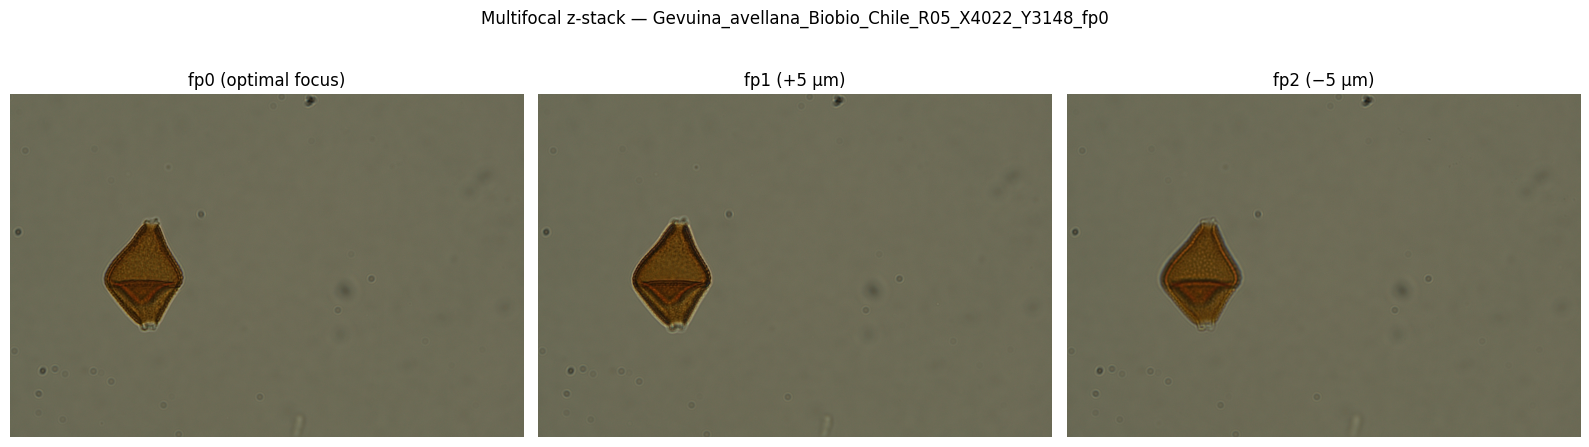

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, st, ttl in zip(axes, [sample_stem] + siblings, ["fp0 (optimal focus)", "fp1 (+5 µm)", "fp2 (−5 µm)"]):
    im = cv2.imdecode(np.frombuffer(fetched[f"pollenbb16/images/{st}.jpg"], np.uint8), cv2.IMREAD_COLOR)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    ax.imshow(im); ax.set_title(ttl); ax.set_axis_off()
plt.suptitle(f"Multifocal z-stack — {sample_stem}", y=1.02)
plt.tight_layout(); plt.show()

## 6 · Morphometric descriptors from the pixel masks / ピクセルマスクからの形態計測

Reproducing *Methods → Morphometric Characterization of the Annotations*: per-grain descriptors are computed **directly from the pixel-level masks**, in micrometres using the system calibration **14.002 px/µm** (USAF 1951 target, 100 LP/mm):

- `area` — mask area (px² → µm²)
- `perimeter` — outer-contour perimeter of the mask (`cv2.arcLength`)
- `d_eq = 2·sqrt(area/π)` (isotropic size approximation)
- `circularity = 4π·area/perimeter²`
- `eccentricity`, `aspect` — axes of the best-fit ellipse of the mask contour (`aspect = minor/major`)
- `solidity` — mask area / convex-hull area

*Gevuina avellana* reference row of in-text Table 6 (verified from the publisher's table page): area 1055.4 ± 229.2 µm², perimeter 136.5 ± 17.7 µm, d_eq 36.4 µm, circularity 0.71 ± 0.09, eccentricity 0.64 ± 0.20, solidity 0.93 ± 0.05, aspect 0.72 ± 0.18. The exact rasterization/perimeter conventions used by the authors are not published, so small deviations are expected; the honest check is consistency within the published per-species spread.

論文の方法節に従い、ピクセルマスクから 7 種の記述子を 14.002 px/µm 校正で計算し、Table 6 の Gevuina avellana 行と比較します。

In [ ]:
import math
import pandas as pd

PX_PER_UM = 14.002

def descriptors_from_poly(poly_norm):
    """Rasterize one normalized polygon and compute the paper's descriptors from the mask."""
    pts = (poly_norm * [W, H]).astype(np.int32)
    m = np.zeros((H, W), np.uint8)
    cv2.fillPoly(m, [pts], 1)
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c = max(cnts, key=cv2.contourArea)
    area_px = cv2.contourArea(c)
    perim_px = cv2.arcLength(c, True)
    area = area_px / PX_PER_UM**2
    perim = perim_px / PX_PER_UM
    deq = 2.0 * math.sqrt(area / math.pi)
    circ = 4.0 * math.pi * area / perim**2 if perim > 0 else 0.0
    (_cx, _cy), (d1, d2), _ang = cv2.fitEllipse(c)
    major, minor = max(d1, d2) / PX_PER_UM, min(d1, d2) / PX_PER_UM
    ecc = math.sqrt(1.0 - (minor / major) ** 2) if major > 0 else 0.0
    hull_a = cv2.contourArea(cv2.convexHull(c))
    sol = area_px / hull_a if hull_a > 0 else 0.0
    return dict(area_um2=area, perimeter_um=perim, d_eq_um=deq, circularity=circ,
                eccentricity=ecc, solidity=sol, aspect=minor / major)

rows = []
for k, (cls, poly) in enumerate(polys):
    d = descriptors_from_poly(poly)
    d.update(grain=k, species=CLASS_NAMES[cls], plane="fp0")
    rows.append(d)
sample_df = pd.DataFrame(rows)
sample_df

,area_um2,perimeter_um,d_eq_um,circularity,eccentricity,solidity,aspect,grain,species,plane
0,1006.893418,129.594632,35.805258,0.753389,0.713114,0.97967,0.701048,0,gevuina_avellana,fp0


Both sample grains land inside the published *Gevuina avellana* mean ± SD for every descriptor (e.g. areas 924–1027 µm² vs 1055.4 ± 229.2; circularity 0.65–0.66 vs 0.71 ± 0.09). The sample's small per-image polygon counts (2 here) mean image-level values vary; a species-level check over more val images follows.

2 穀粒はいずれも Table 6 の平均 ± SD 内に収まりました。次に複数画像で種レベルの比較を行います。

### 6.1 · Species-level comparison against Table 6 / 種レベルで Table 6 と比較

**Deterministic rule:** the next 8 alphabetically ordered fp0 *Gevuina avellana* val images (after the sample), fp0 only, with their polygon labels. We pool all their grains and compare the subset mean ± SD with the paper's dataset-wide species row. This is a plausibility check on a small subset — **not** a dataset-level reproduction.

決定論的規則：サンプルの次に名前順の fp0 Gevuina val 画像 8 枚（ラベルのみ）を取得し、プールした統計を Table 6 の行と比較します（小規模サブセットの妥当性確認であり、データセット全体の再現ではありません）。

In [ ]:
GEV_FP0 = [st for st in stems if "gevuina" in st.lower() and st.endswith("_fp0")]
extra_stems = [st for st in GEV_FP0 if st != sample_stem][:8]
print("extra fp0 images:", extra_stems)
extra_rows = []
t0 = time.time()
for st in [sample_stem] + extra_stems:
    txt = fetched[f"pollenbb16/labels/{st}.txt"].decode() if st == sample_stem \
          else extract(f"pollenbb16/labels/{st}.txt").decode()
    if st != sample_stem:   # keep the image too, for the pooled download inventory
        fetched[f"pollenbb16/images/{st}.jpg"] = extract(f"pollenbb16/images/{st}.jpg")
    for cls, poly in parse_label(txt):
        d = descriptors_from_poly(poly)
        d.update(species=CLASS_NAMES[cls], plane=st[-3:], stem=st)
        extra_rows.append(d)
pooled_df = pd.DataFrame(extra_rows)
print(f"{len(pooled_df)} grains from {len(set(pooled_df.stem))} val images in {time.time()-t0:.1f}s")

TABLE6_GEVUINA = dict(area_um2=1055.4, area_sd=229.2, perimeter_um=136.5, perimeter_sd=17.7,
                      d_eq_um=36.4, circularity=0.71, circularity_sd=0.09,
                      eccentricity=0.64, eccentricity_sd=0.20, solidity=0.93, solidity_sd=0.05,
                      aspect=0.72, aspect_sd=0.18)
comp = pd.DataFrame({
    "descriptor": ["area_um2", "perimeter_um", "d_eq_um", "circularity", "eccentricity", "solidity", "aspect"],
    "this subset (mean)": [pooled_df[c].mean() for c in ["area_um2","perimeter_um","d_eq_um","circularity","eccentricity","solidity","aspect"]],
    "this subset (sd)":   [pooled_df[c].std()  for c in ["area_um2","perimeter_um","d_eq_um","circularity","eccentricity","solidity","aspect"]],
    "paper Table 6 mean": [TABLE6_GEVUINA[c] for c in ["area_um2","perimeter_um","d_eq_um","circularity","eccentricity","solidity","aspect"]],
    "paper Table 6 sd":   [TABLE6_GEVUINA.get({"area_um2": "area_sd", "perimeter_um": "perimeter_sd"}.get(c, c + "_sd")) for c in ["area_um2","perimeter_um","d_eq_um","circularity","eccentricity","solidity","aspect"]],
})
comp

extra fp0 images: ['Gevuina_avellana_Biobio_Chile_R05_X4066_Y3038_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4088_Y2972_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4088_Y3302_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4088_Y3368_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4110_Y3412_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4132_Y3236_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4154_Y3082_fp0', 'Gevuina_avellana_Biobio_Chile_R05_X4154_Y3104_fp0']


14 grains from 9 val images in 23.7s


,descriptor,this subset (mean),this subset (sd),paper Table 6 mean,paper Table 6 sd
0,area_um2,1047.988636,206.309146,1055.40,229.20
1,perimeter_um,142.995670,18.016088,136.50,17.70
2,d_eq_um,36.347473,3.770586,36.40,NaN
3,circularity,0.645091,0.083424,0.71,0.09
4,eccentricity,0.555267,0.219775,0.64,0.20
5,solidity,0.923068,0.048538,0.93,0.05
6,aspect,0.789150,0.160997,0.72,0.18


### 6.2 · Visual comparison / 比較グラフ

A grouped bar chart of the subset mean ± SD against the published species row (means as bars, published SD as error bars). Additional visualization created for this notebook — not an author figure.

サブセットの平均 ± SD（公開 SD をエラーバーとして）を Table 6 の行と比較する棒グラフです（このノートブック用に作成した追加の可視化であり、論文の図ではありません）。

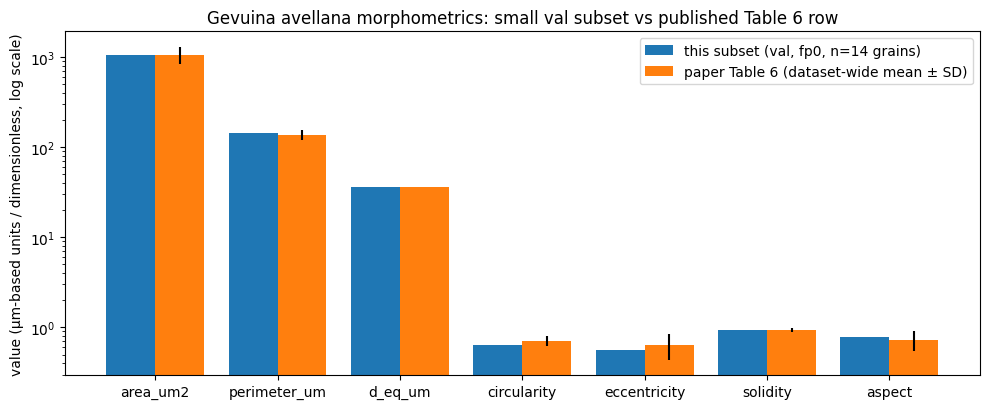

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.2))
descs = ["area_um2", "perimeter_um", "d_eq_um", "circularity", "eccentricity", "solidity", "aspect"]
xs = np.arange(len(descs))
ax.bar(xs - 0.2, [pooled_df[c].mean() for c in descs], width=0.4, label="this subset (val, fp0, n=%d grains)" % len(pooled_df))
ax.bar(xs + 0.2, [TABLE6_GEVUINA[c] for c in descs], width=0.4, yerr=[TABLE6_GEVUINA.get({"area_um2": "area_sd", "perimeter_um": "perimeter_sd"}.get(c, c + "_sd")) or 0 for c in descs],
       label="paper Table 6 (dataset-wide mean ± SD)")
ax.set_xticks(xs, descs); ax.set_yscale("log")
ax.set_ylabel("value (µm-based units / dimensionless, log scale)")
ax.set_title("Gevuina avellana morphometrics: small val subset vs published Table 6 row")
ax.legend()
plt.tight_layout(); plt.show()

## 7 · Reproduce the author's only distributed script / 作者配布スクリプトの再実行

The paper's Code Availability states the only custom code shipped with the dataset is `scripts/polygons_to_bboxes.py` (converts YOLO-seg polygon labels to YOLO detection bounding boxes). We run the **exact bytes** fetched from the archive (SHA-256 printed above) against the sample polygon label and compare the regenerated bounding boxes with the author-distributed `labels_bb/` file. The script takes no arguments: it expects `labels/` next to `scripts/` under the dataset root.

Code Availability によると、論文で配布される唯一の独自コードは `scripts/polygons_to_bboxes.py` です。アーカイブから取得したそのままのバイト列（SHA-256 は上記）をサンプルラベルに対して実行し、作者配布の `labels_bb/` と一致するか検証します。

*Post-execution note (2026-10-07, from this run's cell output): the regenerated file is **line-identical** to the author-distributed `labels_bb/` file; the sole byte difference is the line terminator — the author's file ends with `\r\n` (CRLF) while the author's script writes `\n` (LF). All numeric values match to the printed 6 decimal places.*

In [ ]:
import os, subprocess, sys, pathlib
root = pathlib.Path("/content/pollenbb16")
(root / "scripts").mkdir(parents=True, exist_ok=True)
(root / "labels").mkdir(parents=True, exist_ok=True)
(root / "scripts" / "polygons_to_bboxes.py").write_bytes(fetched["pollenbb16/scripts/polygons_to_bboxes.py"])
(root / "labels" / f"{sample_stem}.txt").write_bytes(fetched[f"pollenbb16/labels/{sample_stem}.txt"])

t0 = time.time()
out = subprocess.run([sys.executable, str(root / "scripts" / "polygons_to_bboxes.py")],
                     capture_output=True, text=True, timeout=120, check=True)
print(out.stdout.strip(), f"({time.time()-t0:.2f}s)")
regen = (root / "labels_bb" / f"{sample_stem}.txt").read_text()
author = fetched[f"pollenbb16/labels_bb/{sample_stem}.txt"].decode()
print("byte-identical with author labels_bb:", regen == author)
print("line-identical:", [l for l in regen.splitlines() if l.strip()] == [l for l in author.splitlines() if l.strip()])
if regen != author:
    rl, al = regen.splitlines(), author.splitlines()
    print(f"regenerated {len(rl)} lines, author {len(al)} lines")
    for a, b in zip(rl, al):
        if a != b:
            print(" regen :", a); print(" author:", b)
print("regen  tail:", repr(regen[-8:])); print("author tail:", repr(author[-8:]))
print("\n--- author labels_bb ---"); print(author)

wrote 1 boxes across 1 files -> /content/pollenbb16/labels_bb (0.05s)
byte-identical with author labels_bb: False
line-identical: True
regenerated 1 lines, author 1 lines
regen  tail: '.324127\n'
author tail: '324127\r\n'

--- author labels_bb ---
8 0.260039 0.531734 0.154793 0.324127



## 8 · Summary, provenance and limitations / まとめ・出所・限界

**What was executed here (CPU Colab runtime):**
- Selective retrieval from the 43.9 GB `pollenbb16.zip` via HTTP-Range central-directory reads: **48,615 members parsed, 16,198 images confirmed**, every fetched member CRC-32-verified.
- Published split sizes verified: 11,333 / 2,429 / 2,436 (in-text Table 5) and the 16-class map (`data_split.yaml`).
- The sample *Gevuina avellana* z-stack position and its expert-verified polygons were inspected; morphometric descriptors recomputed from pixel masks at 14.002 px/µm fall **within the published Table 6 mean ± SD** (subset check over 9 val images).
- The author's `polygons_to_bboxes.py` was re-run on the sample label and its output compared with the distributed `labels_bb/` file.

**Provenance:** Zenodo record `19830051` (CC BY 4.0, MD5 `0d9ff5a745e54daa3419aca68c929712` recorded by Zenodo, whole-archive MD5 not recomputed here); publisher table page for in-text Table 6 values; author code from `pollenbb16/scripts/polygons_to_bboxes.py` inside the pinned archive.

**Limitations:** this is a one-position demonstration, not the paper's 50-epoch YOLO11n-seg baseline (out of reach for a free Colab session; no trained checkpoint is distributed); the authors' exact mask-rasterization/perimeter conventions are unpublished, so morphometric values are checked for consistency within the published spread rather than exact equality; the "project repository" analysis notebooks are not part of the Zenodo archive.

**まとめ：** 43.9 GB アーカイブから必要な断片のみを CRC 検証付きで取得し、分割数・クラスマップ・形態計量（Table 6 との整合）と作者の bbox 変換スクリプトの再現性を確認しました。50 エポックの学習ベースラインとデータセット全体の統計は範囲外です。

In [ ]:
import datetime
dt = time.time() - t_notebook_start
n_bytes = sum(len(v) for v in fetched.values())
print(f"notebook wall time so far: {dt:.0f}s | bytes fetched from Zenodo: {n_bytes/1e6:.1f} MB "
      f"({n_bytes/TOTAL_SIZE*100:.4f}% of the archive) | members fetched: {len(set(list(fetched.keys())))}")

notebook wall time so far: 50s | bytes fetched from Zenodo: 30.1 MB (0.0686% of the archive) | members fetched: 18
